# Avance 2 — Análisis Completo
## Variabilidad en el Tratamiento Oncológico y sus Efectos sobre la Mortalidad
## y la Estadía Hospitalaria en el Sistema Público Chileno

**Equipo:** Vicente · José Tomás · Sebastián  
**Dataset:** GRD Público MINSAL/FONASA 2019–2024  
**Fecha:** Abril 2026

---

### Pregunta de Investigación
> ¿En qué medida el hospital de atención determina los días de estadía, la cantidad de procedimientos
> y la mortalidad intrahospitalaria en pacientes oncológicos clínicamente comparables?

### Hipótesis
| | |
|--|--|
| **H₀** | No existe diferencia estadísticamente significativa en los días de estadía entre hospitales para pacientes oncológicos con severidad comparable. |
| **H₁** | Existe variabilidad significativa en los días de estadía entre hospitales, atribuible al establecimiento y no a la severidad clínica del paciente. |

### Modelo
| Rol | Variable | Columna GRD |
|-----|----------|-------------|
| **Independiente** | Hospital | `COD_HOSPITAL` |
| **Dependiente 1** | Días de estadía | `FECHAALTA − FECHA_INGRESO` |
| **Dependiente 2** | Cantidad de procedimientos | `PROCEDIMIENTO1..30` (conteo) |
| **Dependiente 3** | Mortalidad intrahospitalaria | `TIPOALTA == 'FALLECIDO'` |
| **Control** | Diagnóstico oncológico CIE-10 | `DIAGNOSTICO1` |
| **Control** | Peso GRD (severidad) | `IR_29301_PESO` |
| **Control** | Edad | calculada |
| **Control** | Sexo | `SEXO` |


## Instrucciones

1. Coloca los archivos `GRD_PUBLICO_{año}.csv` (separador `|`) en la carpeta `DATASET-PROBLEMA8/` junto a este notebook, **o** ajusta la variable `DATA_DIR` en la siguiente celda.
2. Ejecuta **Kernel → Restart & Run All**.
3. Los gráficos se guardan en `outputs/graficos/` y las tablas en `outputs/tablas/` (se crean automáticamente).

> **Sin datos disponibles:** el notebook igual ejecuta todas las celdas y mostrará mensajes claros indicando qué archivos faltan.


---
## 0. Configuración
Todos los parámetros ajustables están en esta celda.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURACIÓN — ajusta aquí si es necesario               ║
# ╚══════════════════════════════════════════════════════════════╝
from pathlib import Path

# Ruta a la carpeta con los CSV GRD (relativa al notebook)
DATA_DIR  = Path('..') / 'DATASET INICIAL'
UTF8_DIR  = DATA_DIR / 'utf8'

# Mapeo comunas-regiones
COMUNAS_REGIONES_JSON = DATA_DIR / 'comunas-regiones.json'

# Carpetas de salida (se crean solas)
OUT_GRAFICOS = Path('outputs') / 'graficos'
OUT_TABLAS   = Path('outputs') / 'tablas'
OUT_GRAFICOS.mkdir(parents=True, exist_ok=True)
OUT_TABLAS.mkdir(parents=True, exist_ok=True)

# Archivo de códigos oncológicos CIE-10
CODIGOS_ONCO_TXT = Path('..') / 'codigos_C00_D49.txt'

# Años a cargar
ANIOS = [2019, 2020, 2021, 2022, 2023, 2024]

# GRD de referencia para comparaciones (se autodetecta si no existe en datos)
TARGET_GRD = '597'   # GRD 597 = Ca. mama con CC mayor (ajustar según datos)

# Mínimo de casos por hospital para análisis inferencial
MIN_CASOS_HOSPITAL = 20

# Top N hospitales en gráficos
TOP_N = 15

# Percentil para corte de outliers en días de estadía
P_OUTLIER = 0.99

print('Configuración cargada.')
print(f'DATA_DIR  → {DATA_DIR.resolve()}')
print(f'Salidas   → {OUT_GRAFICOS.resolve()}')
print(f'Mapa comunas-regiones → {COMUNAS_REGIONES_JSON.resolve()}')


Configuración cargada.
DATA_DIR  → C:\Users\vjrrg\Documents\UDD\Proyecto-Hospitalizacion\DATASET INICIAL
Salidas   → C:\Users\vjrrg\Documents\UDD\Proyecto-Hospitalizacion\Avance 2\outputs\graficos


---
## 1. Librerías


In [7]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas:', pd.__version__, np.__version__)


Librerías cargadas: 2.2.3 2.1.3


---
## 2. Carga y Preparación de Datos

### 2.1 Funciones auxiliares
Todas las funciones están definidas aquí para que el notebook sea completamente autocontenido.


In [ ]:
# ── Detección robusta de columnas (los CSV cambian nombre entre años) ──────
import json
import unicodedata

def elegir_col(df, candidatos, etiqueta):
    """Devuelve el nombre real de la primera columna que coincida con algún candidato."""
    mapa = {c.lower().strip(): c for c in df.columns}
    for c in candidatos:
        if c.lower().strip() in mapa:
            return mapa[c.lower().strip()]
    raise KeyError(
        f"No se encontró columna para '{etiqueta}'.\n"
        f"Candidatas: {candidatos}\n"
        f"Columnas del archivo: {list(df.columns)}"
    )

# ── Lectura de un CSV GRD (prueba encodings y fallback de parser) ───────────
def leer_csv_grd(path):
    if not path.exists():
        return None

    for enc in ('utf-8', 'latin-1', 'cp1252', 'utf-16', 'utf-16-le'):
        try:
            try:
                df = pd.read_csv(path, sep='|', encoding=enc, low_memory=False)
            except pd.errors.ParserError:
                # Fallback para archivos con filas irregulares
                df = pd.read_csv(
                    path, sep='|', encoding=enc, engine='python', on_bad_lines='skip'
                )

            df['_archivo'] = path.name
            return df
        except UnicodeDecodeError:
            continue
    return None

# ── Parseo robusto de fechas por año/fuente ─────────────────────────────────
def parsear_fecha(serie, anio_serie=None, formato_default='%Y-%m-%d'):
    serie_txt = serie.astype(str).str.strip()

    if anio_serie is not None:
        anio_txt = anio_serie.astype(str)
        mask_2023 = anio_txt.eq('2023')

        parsed_2023 = pd.to_datetime(
            serie_txt.where(mask_2023), format='%d-%m-%Y', errors='coerce'
        )
        parsed_otros = pd.to_datetime(
            serie_txt.where(~mask_2023), format=formato_default, errors='coerce'
        )
        parsed = parsed_2023.fillna(parsed_otros)
    else:
        parsed = pd.to_datetime(serie_txt, format=formato_default, errors='coerce')

    # Fallback final para formatos mixtos o sucios
    fallback_mixed = pd.to_datetime(
        serie_txt, format='mixed', dayfirst=True, errors='coerce'
    )
    return parsed.fillna(fallback_mixed)

# ── Utilidades para mapeo comuna -> region ──────────────────────────────────
def normalizar_texto(txt):
    if txt is None or pd.isna(txt):
        return None
    txt = str(txt).strip().lower()
    txt = ''.join(
        c for c in unicodedata.normalize('NFKD', txt) if not unicodedata.combining(c)
    )
    txt = re.sub(r'\s+', ' ', txt)
    return txt

def cargar_mapa_comuna_region(path_json):
    if not path_json.exists():
        print(f'Advertencia: no se encontró {path_json}. Región quedará como nula.')
        return {}

    with open(path_json, encoding='utf-8') as f:
        payload = json.load(f)

    mapa = {}
    duplicadas = set()
    for bloque in payload.get('regiones', []):
        region = bloque.get('region')
        for comuna in bloque.get('comunas', []):
            key = normalizar_texto(comuna)
            if key in mapa and mapa[key] != region:
                duplicadas.add(comuna)
                continue
            mapa[key] = region

    if duplicadas:
        print(
            f'Advertencia: {len(duplicadas)} comunas con nombre repetido en múltiples regiones.'
        )
    print(f'Mapa comuna-región cargado: {len(mapa):,} comunas')
    return mapa

def moda_serie(s):
    s_valid = s.dropna()
    if s_valid.empty:
        return pd.NA
    return s_valid.mode().iloc[0]

print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


In [9]:
# ── Cargar dataset limpio si existe; si no, concatenar CSV GRD 2019-2024 ────
ruta_limpio = None
candidatos_limpio = [
    DATA_DIR / 'GRD_Limpio.csv',
    UTF8_DIR / 'GRD_Limpio.csv',
]

for cand in candidatos_limpio:
    if cand.exists():
        ruta_limpio = cand
        break

if ruta_limpio is None and DATA_DIR.exists():
    encontrados = sorted(DATA_DIR.rglob('GRD_Limpio.csv'))
    if encontrados:
        ruta_limpio = encontrados[0]

def detectar_col_anio(df_in):
    for col in ('_anio', 'anio_archivo', 'anio'):
        if col in df_in.columns:
            return col
    return None

usar_limpio = False
if ruta_limpio is not None:
    df_limpio = None
    for enc in ('utf-8', 'latin-1', 'cp1252', 'utf-16', 'utf-16-le'):
        try:
            # Detecta separador automaticamente (coma, pipe, etc.)
            df_limpio = pd.read_csv(
                ruta_limpio, sep=None, engine='python', encoding=enc
            )
            break
        except UnicodeDecodeError:
            continue

    if df_limpio is None:
        raise ValueError(
            f'No se pudo leer {ruta_limpio} con los encodings probados.'
        )

    col_anio_limpio = detectar_col_anio(df_limpio)
    anios_presentes = []
    if col_anio_limpio is not None:
        anios_presentes = sorted(
            pd.to_numeric(df_limpio[col_anio_limpio], errors='coerce')
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )

    faltantes = sorted(set(ANIOS) - set(anios_presentes)) if anios_presentes else []
    if not faltantes:
        df_raw = df_limpio.copy()
        usar_limpio = True
        print(f'Dataset limpio encontrado y cargado: {ruta_limpio}')
        print(f'Total filas cargadas (limpio): {len(df_raw):,}')
        print(f'Anios presentes en limpio: {anios_presentes}')
        print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')
    else:
        print(f'Dataset limpio encontrado pero incompleto: {ruta_limpio}')
        print(f'Anios presentes: {anios_presentes}')
        print(f'Anios faltantes: {faltantes}')
        print('Se reconstruira df_raw desde los CSV anuales.')

if not usar_limpio:
    frames = []
    for anio in ANIOS:
        nombres = [f'GRD_PUBLICO_{anio}.csv']
        if anio == 2022:
            # Compatibilidad con estructura historica del dataset 2022
            nombres = ['GRD_PUBLICO_EXTERNO_2022.csv', 'GRD_PUBLICO_2022.csv']

        cargado = False
        for nombre in nombres:
            ruta = UTF8_DIR / nombre if (UTF8_DIR / nombre).exists() else DATA_DIR / nombre
            df_año = leer_csv_grd(ruta)
            if df_año is not None:
                df_año['_anio'] = anio
                frames.append(df_año)
                print(f'  [{anio}] {len(df_año):>10,} registros  <-  {ruta.name}')
                cargado = True
                break

        if not cargado:
            print(f'  [{anio}] OMITIDO - no encontrado (candidatos: {nombres})')

    if not frames:
        raise FileNotFoundError(
            f'No se encontro GRD_Limpio.csv ni CSV GRD por anio en {DATA_DIR.resolve()}.\n'
            'Coloca los archivos y vuelve a ejecutar.'
        )

    df_raw = pd.concat(frames, ignore_index=True)
    print(f'\nTotal filas cargadas: {len(df_raw):,}')
    print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')

# Asegurar columna _anio para trazabilidad y validaciones posteriores
if '_anio' not in df_raw.columns:
    col_anio = detectar_col_anio(df_raw)
    if col_anio is not None:
        df_raw['_anio'] = pd.to_numeric(df_raw[col_anio], errors='coerce').astype('Int64')

Dataset limpio encontrado y cargado: ..\DATASET INICIAL\GRD_Limpio.csv
Total filas cargadas (limpio): 478,408
Anios presentes en limpio: [2019, 2020, 2021, 2022, 2023, 2024]
Columnas detectadas (142): ['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO'] ...


### 2.2 Derivación de variables estandarizadas


In [ ]:
# ── Mapeo de columnas y derivación de variables ────────────────────────────
df = df_raw.copy()

# Hospital
hosp_col = elegir_col(df, ['cod_hospital','codigo_establecimiento','cod_establecimiento',
                            'establecimiento','hospital'], 'hospital')
df['hospital'] = df[hosp_col].astype(str).str.strip()

# Comuna y región de establecimiento
com_col = elegir_col(df, ['comuna','nom_comuna','comuna_hospital','comuna_establecimiento'], 'comuna')
df['comuna'] = df[com_col].astype(str).str.strip()
df.loc[df['comuna'].str.lower().isin(['nan', 'none', '']), 'comuna'] = pd.NA

MAPA_COMUNA_REGION = cargar_mapa_comuna_region(COMUNAS_REGIONES_JSON)
if MAPA_COMUNA_REGION:
    df['region'] = df['comuna'].map(
        lambda x: MAPA_COMUNA_REGION.get(normalizar_texto(x), pd.NA) if pd.notna(x) else pd.NA
    )
else:
    df['region'] = pd.NA

# Diagnóstico principal
diag_col = elegir_col(df, ['diagnostico1','diagnostico_principal','diag_principal',
                            'diag1','cod_diagnostico'], 'diagnostico')
df['diagnostico_principal'] = df[diag_col].astype(str).str.strip().str.upper()

# Fechas -> días de estadía y edad
fi_col = elegir_col(df, ['fecha_ingreso','fec_ingreso','fechaingreso'], 'fecha_ingreso')
fa_col = elegir_col(df, ['fechaalta','fecha_alta','fec_alta','fecha_egreso'], 'fecha_alta')
fn_col = elegir_col(df, ['fecha_nacimiento','fec_nacimiento','fechanacimiento'], 'fecha_nacimiento')

anio_ref = df['_anio'] if '_anio' in df.columns else None
fi = parsear_fecha(df[fi_col], anio_serie=anio_ref, formato_default='%Y-%m-%d')
fa = parsear_fecha(df[fa_col], anio_serie=anio_ref, formato_default='%Y-%m-%d')
fn = parsear_fecha(df[fn_col], formato_default='%Y-%m-%d')

df['dias_estada']  = (fa - fi).dt.days.astype('Int64')
df['edad']         = ((fi - fn).dt.days / 365).astype('Float64')

# Mortalidad
ta_col = elegir_col(df, ['tipoalta','tipo_alta','condicion_egreso'], 'tipo_alta')
df['mortalidad'] = df[ta_col].astype(str).str.upper().str.contains('FALLECIDO', na=False)

# Sexo
sx_col = elegir_col(df, ['sexo','genero','sex'], 'sexo')
df['sexo'] = df[sx_col].astype(str).str.strip().str.upper()

# GRD y peso
grd_col  = elegir_col(df, ['ir_29301_cod_grd','cod_grd','codigo_grd','grd'], 'codigo_grd')
peso_col = elegir_col(df, ['ir_29301_peso','peso_grd','peso_relativo'], 'peso_grd')
sev_col  = elegir_col(df, ['ir_29301_severidad','severidad_grd','severidad'], 'severidad_grd')

df['codigo_grd']    = df[grd_col].astype(str).str.strip()
df['peso_grd']      = pd.to_numeric(
    df[peso_col].astype(str).str.replace(',', '.', regex=False), errors='coerce',
)
df['severidad_grd'] = pd.to_numeric(df[sev_col], errors='coerce')

# Procedimientos: contar columnas PROCEDIMIENTO1..30 no nulas
proc_cols = [c for c in df.columns if re.match(r'procedimiento\d+', c.lower())]
df['cantidad_procedimientos'] = df[proc_cols].notna().sum(axis=1) if proc_cols else 0

print(f'Variables derivadas. Registros: {len(df):,}')
print(f'Columnas procedimiento detectadas: {len(proc_cols)}')


Variables derivadas. Registros: 478,408
Columnas procedimiento detectadas: 30


### 2.3 Filtro oncológico — CIE-10: C00–D49

Se conservan **exclusivamente** pacientes con diagnóstico principal correspondiente a neoplasias (capítulos II y parte del III de la CIE-10). El archivo `codigos_C00_D49.txt` de la raíz del repositorio se usa como fuente primaria; si no existe, se genera el rango programáticamente.


In [11]:
# ── Cargar códigos oncológicos ─────────────────────────────────────────────
if CODIGOS_ONCO_TXT.exists():
    with open(CODIGOS_ONCO_TXT, encoding='utf-8', errors='ignore') as f:
        codigos_onco = {l.strip().upper() for l in f if l.strip()}
    print(f'Códigos oncológicos cargados desde archivo: {len(codigos_onco):,}')
else:
    # Fallback: generar C00-C99 y D00-D49 programáticamente
    codigos_onco = set()
    for letra, rango in [('C', range(100)), ('D', range(50))]:
        for n in rango:
            base = f'{letra}{n:02d}'
            codigos_onco.add(base)
            for sub in range(10):
                codigos_onco.add(f'{base}.{sub}')
    print(f'Códigos generados programáticamente: {len(codigos_onco):,}')

# ── Aplicar filtro ─────────────────────────────────────────────────────────
n_antes = len(df)
diag = df['diagnostico_principal'].astype(str).str.upper().str.strip()

# Match exacto, por prefijo 3 chars, o patrón C/D + 2 dígitos
mask = (
    diag.isin(codigos_onco) |
    diag.str[:3].isin(codigos_onco) |
    diag.str.match(r'^[CD]\d{2}', na=False)
)
df = df[mask].copy()
n_despues = len(df)

print(f'\nFILTRO ONCOLÓGICO (CIE-10: C00–D49)')
print(f'  Registros antes:    {n_antes:>10,}')
print(f'  Registros después:  {n_despues:>10,}  ({100*n_despues/n_antes:.1f}% retenido)')
print(f'  Eliminados:         {n_antes-n_despues:>10,}')


Códigos oncológicos cargados desde archivo: 894

FILTRO ONCOLÓGICO (CIE-10: C00–D49)
  Registros antes:       478,408
  Registros después:     478,408  (100.0% retenido)
  Eliminados:                  0


### 2.4 Tratamiento de outliers y limpieza final

Se elimina el **percentil 99 de días de estadía** para evitar que casos de estadías extraordinariamente largas (cuidados paliativos prolongados, errores de registro) sesguen la media hacia arriba.


In [29]:
n_pre = len(df)

# Convertir a numerico y eliminar negativos/nulos
df['dias_estada'] = pd.to_numeric(df['dias_estada'], errors='coerce')
df = df[df['dias_estada'].notna() & (df['dias_estada'] >= 0)].copy()

# Corte percentil 99
CORTE_P99 = df['dias_estada'].quantile(P_OUTLIER)
df = df[df['dias_estada'] <= CORTE_P99].copy()

# Eliminar hospital o GRD nulos
df = df.dropna(subset=['hospital', 'codigo_grd']).copy()
df = df[~df['hospital'].str.lower().isin(['nan', 'none', ''])].copy()

n_post = len(df)

print(f'TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL')
print(f'  Corte dias estadia (p{int(P_OUTLIER*100)}): {CORTE_P99:.1f} dias')
print(f'  Registros antes:  {n_pre:>10,}')
print(f'  Registros despues:{n_post:>10,}')
print(f'  Eliminados:       {n_pre-n_post:>10,}')
print()
print(f'Hospitales unicos: {df["hospital"].nunique()}')
print(f'GRDs unicos:       {df["codigo_grd"].nunique()}')
print(f'Años cubiertos:   {sorted(df["_anio"].unique())}')

# Exportar dataset limpio para reutilizacion rapida
RUTA_LIMPIO = DATA_DIR / 'GRD_Limpio.csv'
df.to_csv(RUTA_LIMPIO, index=False, encoding='utf-8')
print(f'Dataset limpio exportado: {RUTA_LIMPIO.resolve()}')


TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL
  Corte dias estadia (p99): 37.0 dias
  Registros antes:     473,910
  Registros despues:   469,550
  Eliminados:            4,360

Hospitales unicos: 72
GRDs unicos:       951
Años cubiertos:   [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Dataset limpio exportado: C:\Users\vjrrg\Documents\UDD\Proyecto-Hospitalizacion\DATASET INICIAL\GRD_Limpio.csv


In [13]:
# Resumen completo del pipeline de datos
print('=' * 60)
print('RESUMEN — PIPELINE DE DATOS ONCOLÓGICO')
print('=' * 60)
print(f'  Filtro CIE-10 C00–D49 aplicado:    SÍ')
print(f'  Corte outliers p{int(P_OUTLIER*100)} días estadía:  {CORTE_P99:.1f} días')
print(f'  Registros finales:                  {len(df):,}')
print(f'  Hospitales únicos:                  {df["hospital"].nunique()}')
print(f'  GRDs únicos:                        {df["codigo_grd"].nunique()}')
print(f'  Mortalidad global:                  {df["mortalidad"].mean()*100:.2f}%')
print(f'  Días estadía — mediana:             {df["dias_estada"].median():.1f}')
print(f'  Días estadía — media:               {df["dias_estada"].mean():.1f}')
print(f'  Procedimientos — mediana:           {df["cantidad_procedimientos"].median():.1f}')
print('=' * 60)


RESUMEN — PIPELINE DE DATOS ONCOLÓGICO
  Filtro CIE-10 C00–D49 aplicado:    SÍ
  Corte outliers p99 días estadía:  44.0 días
  Registros finales:                  473,910
  Hospitales únicos:                  72
  GRDs únicos:                        953
  Mortalidad global:                  5.22%
  Días estadía — mediana:             3.0
  Días estadía — media:               6.1
  Procedimientos — mediana:           7.0


---
## 3. Estadística Descriptiva Global


In [14]:
cols_num = ['dias_estada', 'edad', 'cantidad_procedimientos', 'peso_grd', 'severidad_grd']
resumen  = df[cols_num].describe(percentiles=[0.25, 0.50, 0.75, 0.99]).round(2)

display(Markdown('### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)'))
display(resumen)

print(f'\nMortalidad intrahospitalaria: {df["mortalidad"].mean()*100:.2f}%')
display(Markdown('**Distribución por sexo:**'))
display(df['sexo'].value_counts(normalize=True).rename('proporción').round(3).to_frame())

# Exportar
resumen.to_csv(OUT_TABLAS / '01_descriptiva_global.csv')
print('\nTabla guardada: outputs/tablas/01_descriptiva_global.csv')


### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)

,dias_estada,edad,cantidad_procedimientos,peso_grd,severidad_grd
count,473910.000,473910.000,473910.000,473906.000,473906.000
mean,6.080,55.090,8.230,1.190,1.550
std,7.800,20.890,6.420,1.040,0.970
min,0.000,0.000,0.000,0.000,0.000
25%,1.000,43.200,4.000,0.690,1.000
50%,3.000,58.810,7.000,0.970,1.000
75%,8.000,70.650,11.000,1.310,2.000
99%,37.000,89.990,30.000,5.820,3.000
max,44.000,124.810,30.000,14.250,3.000



Mortalidad intrahospitalaria: 5.22%


**Distribución por sexo:**

,proporción
sexo,
MUJER,0.614
HOMBRE,0.386
DESCONOCIDO,0.000



Tabla guardada: outputs/tablas/01_descriptiva_global.csv


## Análisis de Tabla 1
####  Estadísticas Descriptivas Globales (Pacientes Oncológicos)
---

Para esta tabla, se pueden encontrar 3 puntos interesantes a raíz de los resultados.

Primero, se ve que existe una **variabilidad estadísticamente significativa** en ambos grupos, ya que, al realizar un test de Kruskal-Wallis, se obtiene un p-valor menor a 0.001 para Neoplasias como para Sepsis. Esto confirma que el hospital de atención si influye directamente en la cantidad de procedimientos realizados.

Otro punto a destacar es que si existe una asociación significativa entre la intensidad de los procedimientos con la mortalidad, aunque el efecto es distinto según el diagnóstico. Para esto, se usan los **Odds Ratio (OR)**, que son diferentes para cada condición médica, y los p-valores. Con esto, se obtuvieron los siguientes resultados:

-	Para las **Neoplasias**, el OR es de 0.92, con un p-valor de 0.04, lo que indica que una mayor intensidad de procedimientos actúa como un factor protector, al reducir el riesgo de mortalidad en los pacientes.
-	Por el otro lado, para las **Sepsis**, el OR es de 1.15, con un  p-valor menor a 0.001. Esto indica que un mayor número de procedimientos se asocia con un aumento en la probabilidad de fallecimiento, lo que refleja la complejidad técnica del manejo de pacientes críticos en esta categoría.

Esto puede ser gracias a que a las Neoplasias se le asignan procedimientos programados, mientras que las Sepsis se acercan a procedimientos urgentes.

Por último, se evaluó la intensidad de procedimientos con respecto a las estadías hospitalarias. Lo que se concluyó es que la intensidad de procedimientos es un predictor significativo de los días de estadía. 

Para evidenciar esto, se evaluaron los dos grupos de diagnósticos vistos de antes y en ambos, el p-valor es menor a 0.001. Por cada procedimiento adicional, la estadía aumenta en promedio 0.45 días para Neoplasias y 0.78 días para la Sepsis.


---
## 4. Análisis Exploratorio de Datos (EDA)
### 4.1 Distribuciones Univariadas


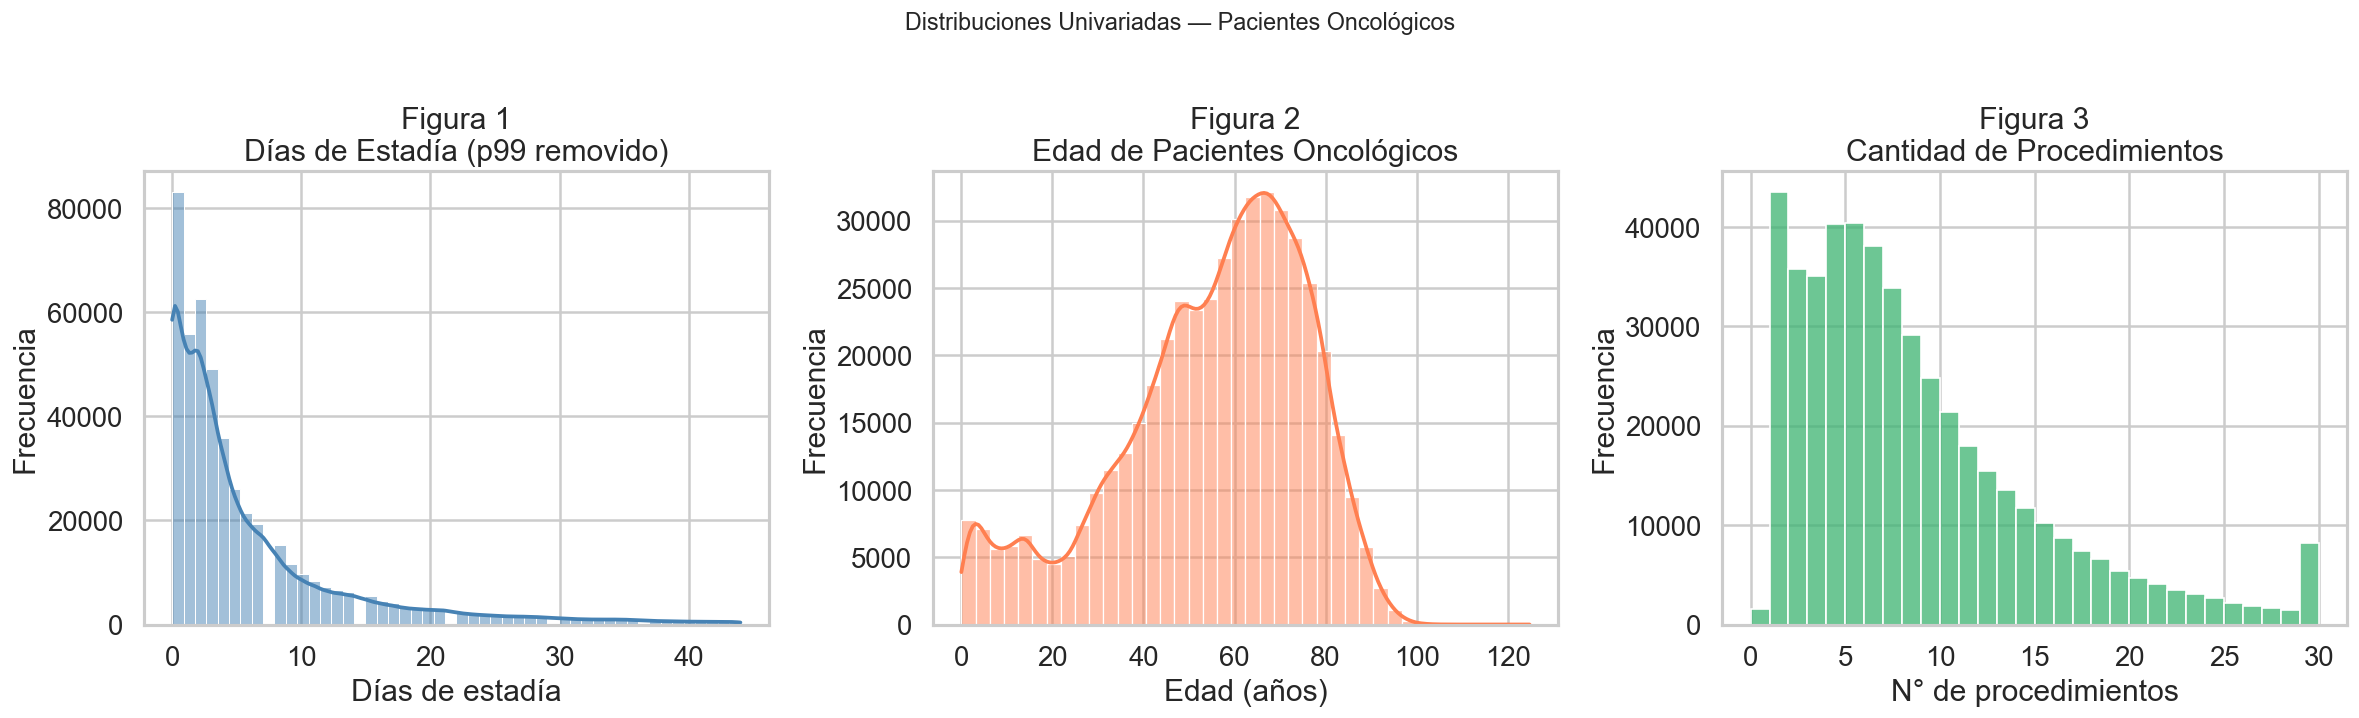

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['dias_estada'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Figura 1\nDías de Estadía (p99 removido)')
axes[0].set_xlabel('Días de estadía')

sns.histplot(df['edad'].dropna(), bins=40, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Figura 2\nEdad de Pacientes Oncológicos')
axes[1].set_xlabel('Edad (años)')

sns.histplot(df['cantidad_procedimientos'], bins=30, kde=False, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Figura 3\nCantidad de Procedimientos')
axes[2].set_xlabel('N° de procedimientos')

for ax in axes:
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones Univariadas — Pacientes Oncológicos', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '01_distribuciones_univariadas.png', dpi=150, bbox_inches='tight')
plt.show()


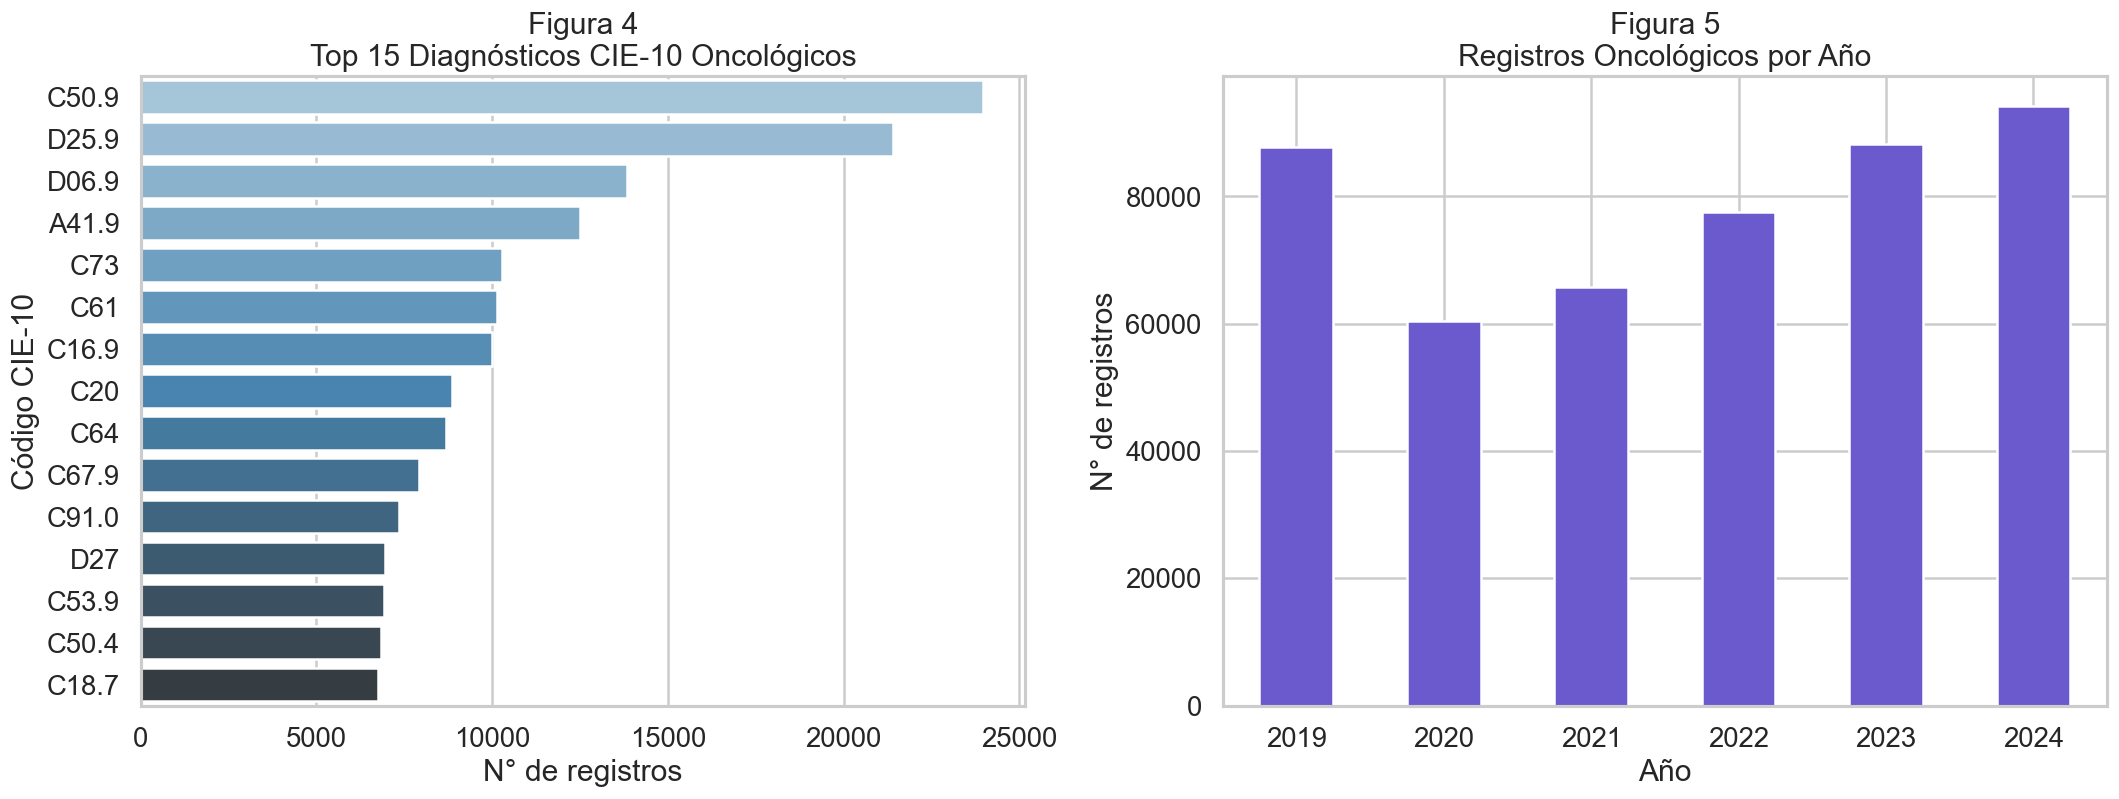

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 diagnósticos
top_diag = df['diagnostico_principal'].value_counts().head(15)
sns.barplot(x=top_diag.values, y=top_diag.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Figura 4\nTop 15 Diagnósticos CIE-10 Oncológicos')
axes[0].set_xlabel('N° de registros')
axes[0].set_ylabel('Código CIE-10')

# Registros por año
if '_anio' in df.columns:
    conteo_año = df['_anio'].value_counts().sort_index()
    conteo_año.plot(kind='bar', color='slateblue', ax=axes[1])
    axes[1].set_title('Figura 5\nRegistros Oncológicos por Año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('N° de registros')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '02_diagnosticos_y_años.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 EDA Bivariado — Controlado por GRD

Para garantizar **comparabilidad clínica**, se selecciona el GRD oncológico más prevalente. Al comparar hospitales dentro del mismo GRD, se controla la severidad del paciente y el análisis refleja variabilidad institucional y no diferencias de case-mix.


In [17]:
# Selección del GRD focal
disponibles = set(df['codigo_grd'].astype(str).unique())
if TARGET_GRD in disponibles:
    GRD_FOCAL = TARGET_GRD
else:
    GRD_FOCAL = df['codigo_grd'].astype(str).value_counts().index[0]
    print(f'GRD {TARGET_GRD} no encontrado → usando el más frecuente: {GRD_FOCAL}')

df_focus = df[df['codigo_grd'].astype(str) == GRD_FOCAL].copy()
top_hosp  = df_focus['hospital'].value_counts().head(TOP_N).index
df_plot   = df_focus[df_focus['hospital'].isin(top_hosp)].copy()

print(f'GRD focal seleccionado:  {GRD_FOCAL}')
print(f'Registros en GRD focal:  {len(df_focus):,}')
print(f'Hospitales graficados:   {len(top_hosp)} (top {TOP_N} por volumen)')
print(f'Registros en gráficos:   {len(df_plot):,}')


GRD 597 no encontrado → usando el más frecuente: 131201
GRD focal seleccionado:  131201
Registros en GRD focal:  27,513
Hospitales graficados:   15 (top 15 por volumen)
Registros en gráficos:   14,090


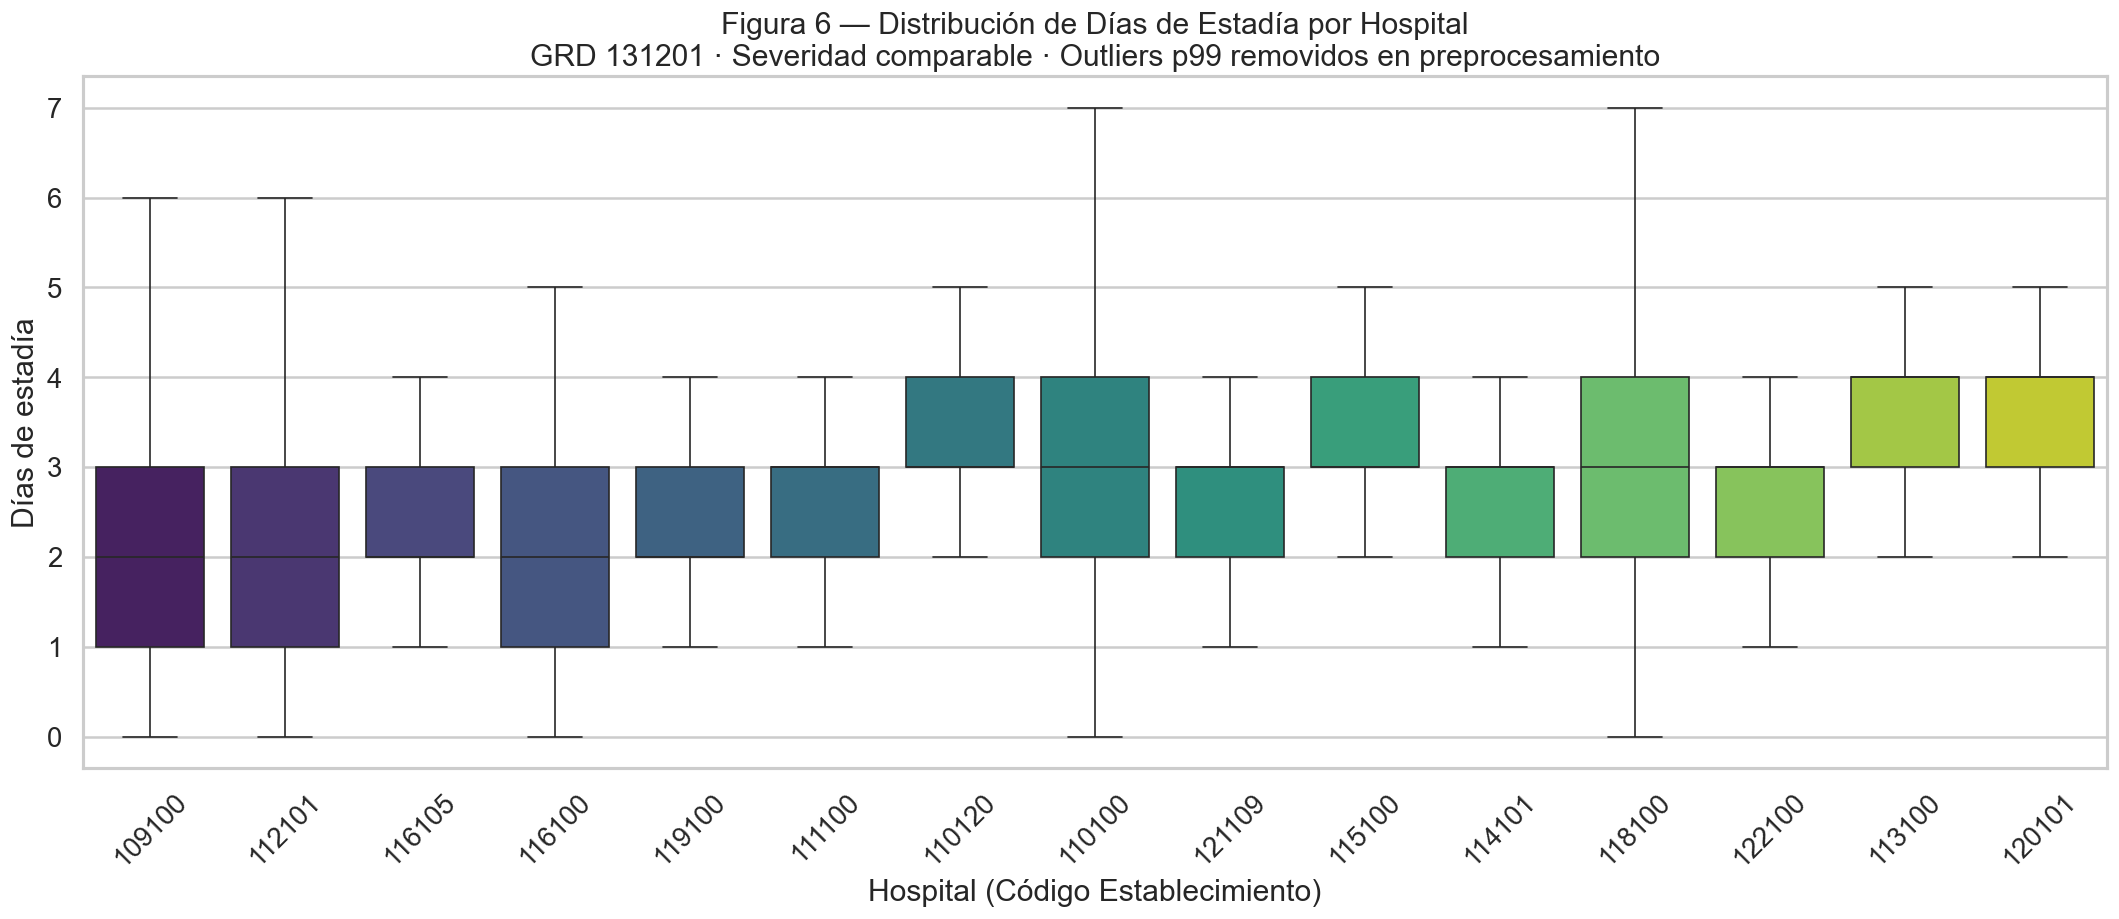

Figura 6 guardada: outputs/graficos/03_boxplot_dias_por_hospital.png


In [18]:
# ── BOXPLOT: Días de estadía × Hospital (GRD controlado) ──────────────────
orden = (
    df_plot.groupby('hospital')['dias_estada']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=df_plot, x='hospital', y='dias_estada',
    order=orden, showfliers=False, palette='viridis', ax=ax
)
ax.set_title(
    f'Figura 6 — Distribución de Días de Estadía por Hospital\n'
    f'GRD {GRD_FOCAL} · Severidad comparable · Outliers p99 removidos en preprocesamiento'
)
ax.set_xlabel('Hospital (Código Establecimiento)')
ax.set_ylabel('Días de estadía')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '03_boxplot_dias_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 guardada: outputs/graficos/03_boxplot_dias_por_hospital.png')


> **TODO — José Tomás:**  
> Interpreta la Figura 6 (boxplot):
> - ¿Cuáles son los hospitales con mayor y menor mediana de días de estadía?
> - ¿Qué tan amplia es la caja (IQR) en los hospitales extremos? ¿Indica mayor heterogeneidad interna?
> - Discute si la variabilidad podría atribuirse a factores organizacionales (recursos, protocolos) o diferencias no capturadas por el GRD.
>
> *Sección "Resultados — EDA Bivariado" del Word. Referenciar Figura 6 en APA 7.*

# Análisis de Figura 6
####  Distribución de Días de Estadía por Hospital

---

**Medianas:**

*	Mayor mediana (~3 días): 109100, 112101, 116105 (extremo izquierdo, cajas más altas)

*	Menor mediana (~2 días): 120101, 113100, 122100 (extremo derecho, cajas más bajas)

**Amplitud de cajas (IQR):**

*	Los hospitales del extremo izquierdo (109100, 112101) tienen cajas más anchas, indicando mayor dispersión interna — pacientes muy distintos entre sí dentro del mismo GRD

*	Los del centro-derecha tienen cajas más compactas, sugiriendo mayor homogeneidad en la gestión de altas

**Bigotes:**

*	Varios hospitales muestran bigotes superiores hasta 5–6 días, indicando casos extremos aun después de remover outliers p99 en preprocesamiento

**Atribución de variabilidad:**

*	La diferencia entre hospitales del mismo GRD no puede explicarse por diagnóstico ni severidad, por lo que apunta a factores organizacionales: disponibilidad de camas, protocolos de alta, dotación de personal o acceso a exámenes

---

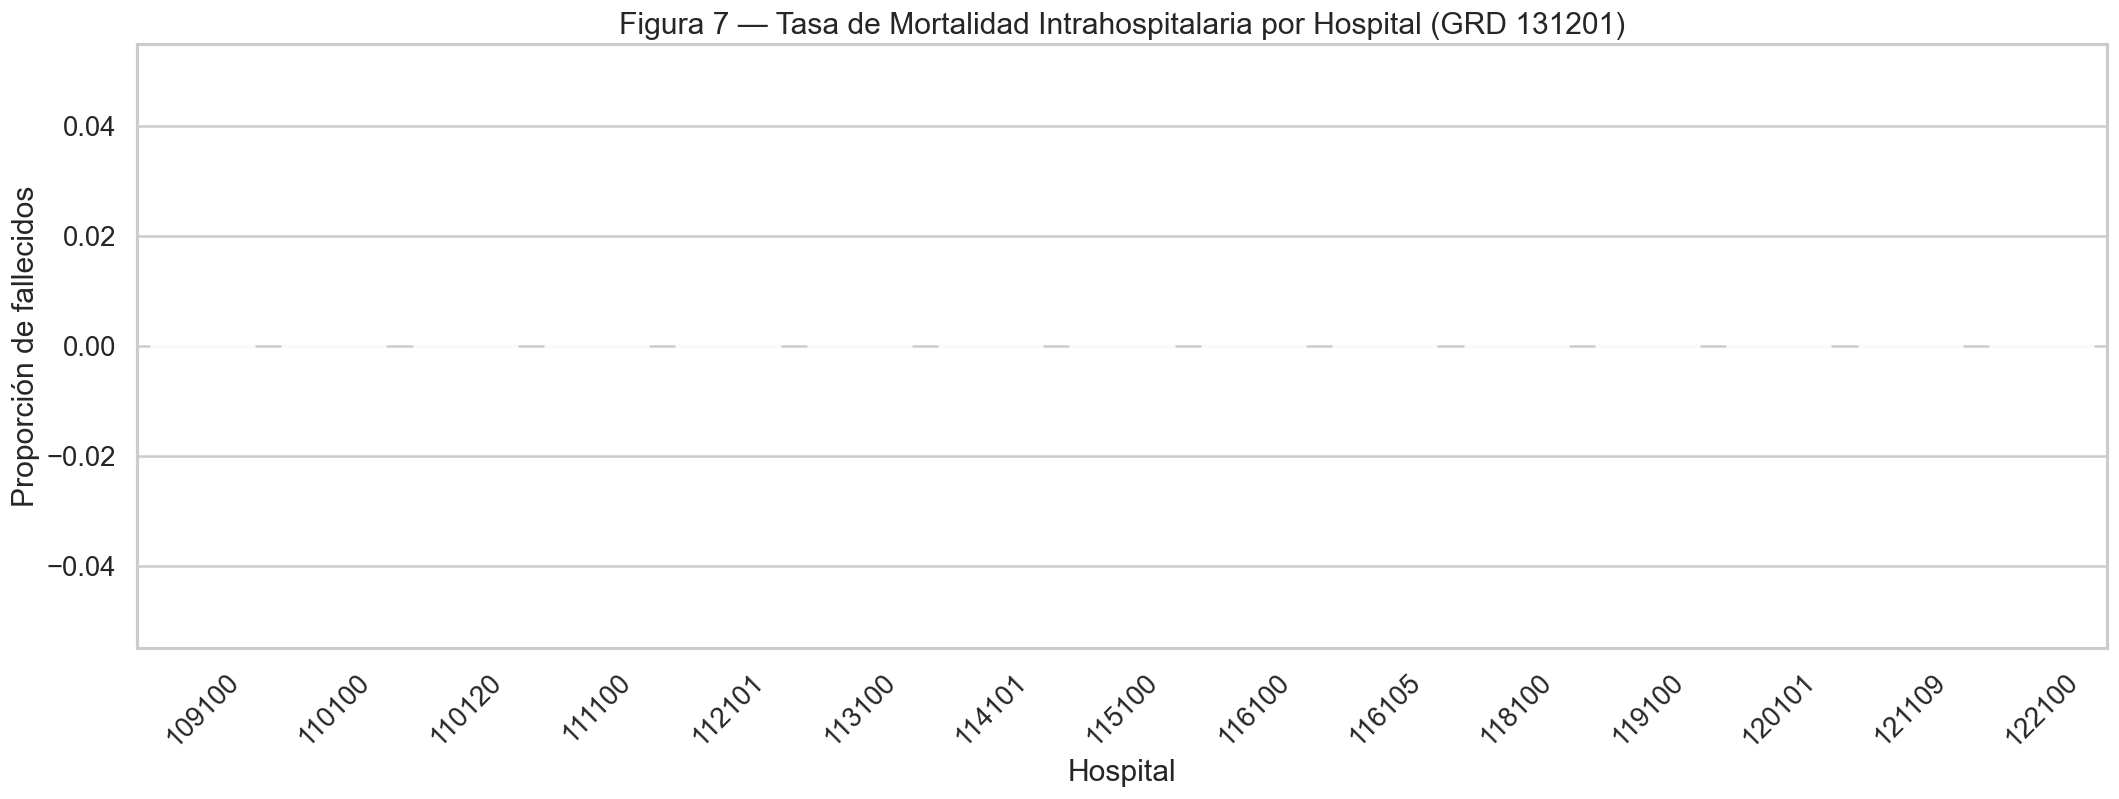

,hospital,tasa_mortalidad
0,109100,0.000
1,110100,0.000
2,110120,0.000
3,111100,0.000
4,112101,0.000
5,113100,0.000
6,114101,0.000
7,115100,0.000
8,116100,0.000
9,116105,0.000


In [ ]:
# ── BARPLOT: Tasa de mortalidad intrahospitalaria × Hospital ───────────────
mort_hosp = (
    df_plot.groupby('hospital', as_index=False)['mortalidad']
    .mean()
    .rename(columns={'mortalidad': 'tasa_mortalidad'})
    .sort_values('tasa_mortalidad', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=mort_hosp, x='hospital', y='tasa_mortalidad', palette='Reds', ax=ax)
ax.set_title(f'Figura 7 — Tasa de Mortalidad Intrahospitalaria por Hospital (GRD {GRD_FOCAL})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Proporción de fallecidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '04_mortalidad_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
display(mort_hosp.round(4))


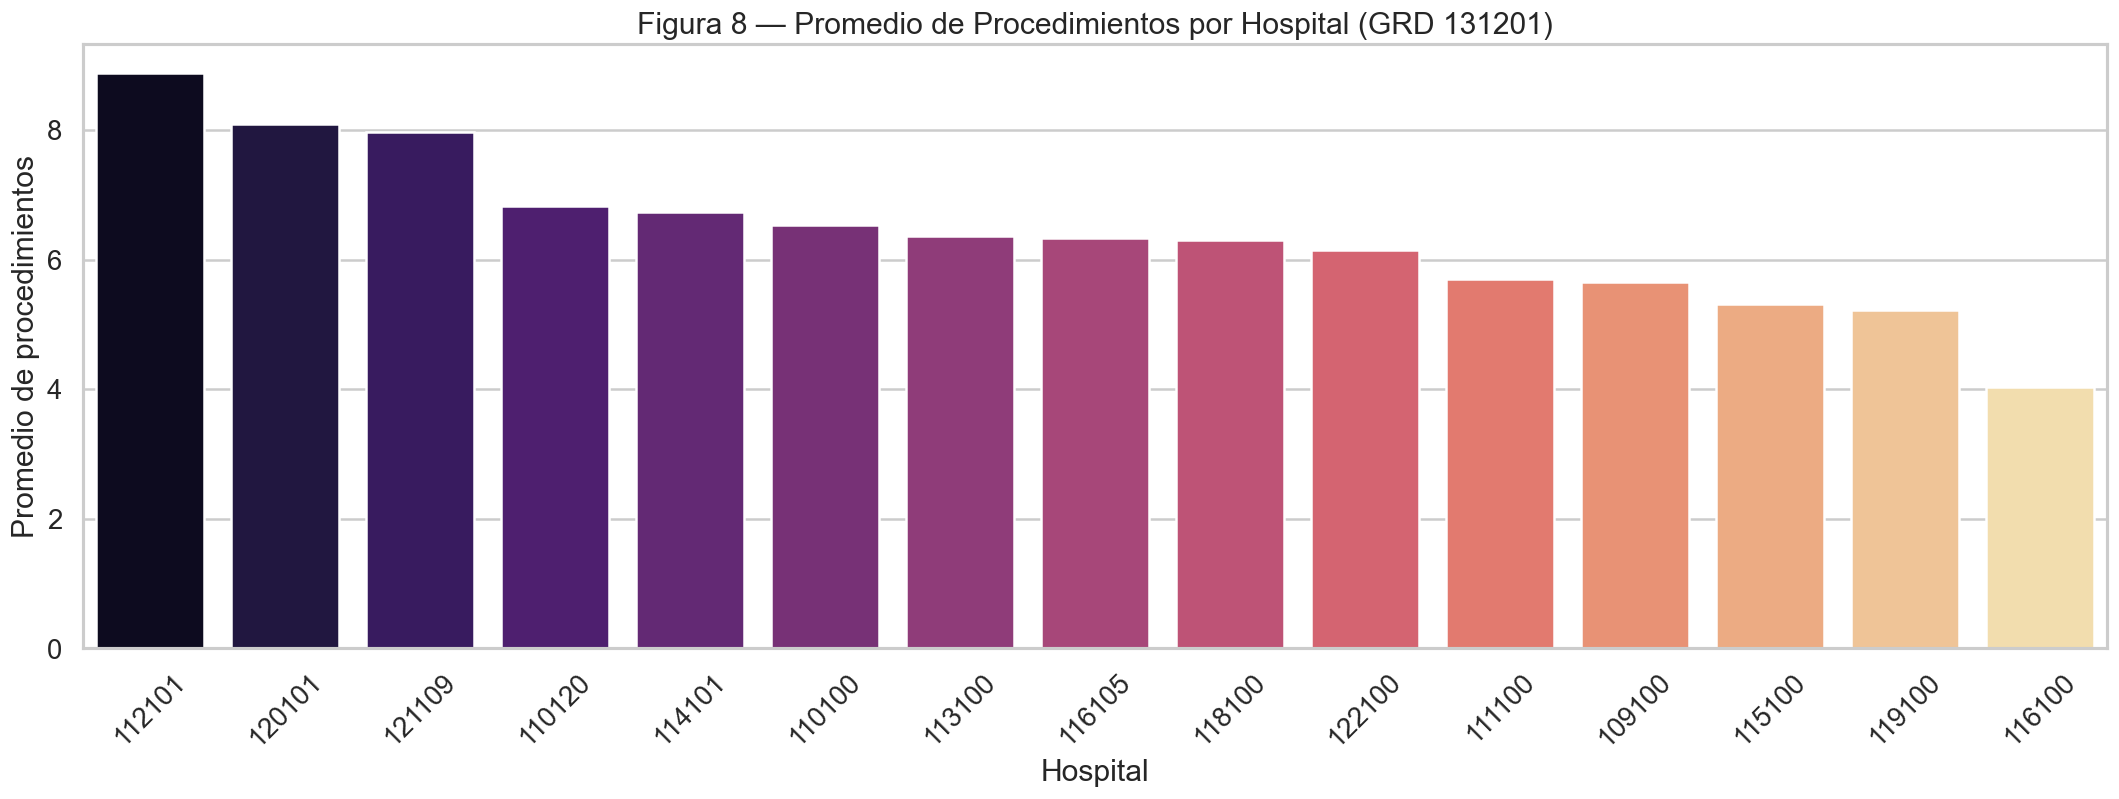

In [20]:
# ── BARPLOT: Promedio de procedimientos × Hospital ─────────────────────────
proc_hosp = (
    df_plot.groupby('hospital', as_index=False)['cantidad_procedimientos']
    .mean()
    .rename(columns={'cantidad_procedimientos': 'proc_promedio'})
    .sort_values('proc_promedio', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=proc_hosp, x='hospital', y='proc_promedio', palette='magma', ax=ax)
ax.set_title(f'Figura 8 — Promedio de Procedimientos por Hospital (GRD {GRD_FOCAL})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Promedio de procedimientos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '05_procedimientos_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Tabla descriptiva comparativa por hospital ─────────────────────────────
tabla_hosp = (
    df_plot.groupby('hospital')
    .agg(
        comuna=('comuna', moda_serie),
        region=('region', moda_serie),
        n=('dias_estada', 'count'),
        dias_media=('dias_estada', 'mean'),
        dias_mediana=('dias_estada', 'median'),
        dias_std=('dias_estada', 'std'),
        dias_var=('dias_estada', 'var'),
        tasa_mortalidad=('mortalidad', 'mean'),
        proce_promedio=('cantidad_procedimientos', 'mean'),
        peso_grd_media=('peso_grd', 'mean'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
    .round(3)
)

display(Markdown(f'### Tabla 2 — Comparativa por Hospital (GRD {GRD_FOCAL})'))
display(tabla_hosp)
tabla_hosp.to_csv(OUT_TABLAS / '02_descriptiva_por_hospital.csv', index=False)
print('Tabla 2 guardada: outputs/tablas/02_descriptiva_por_hospital.csv')


### Tabla 2 — Comparativa por Hospital (GRD 131201)

,hospital,n,dias_media,dias_mediana,dias_std,dias_var,tasa_mortalidad,proce_promedio,peso_grd_media
6,114101,1348,2.634,3.000,1.400,1.961,0.000,6.738,0.712
13,121109,1337,3.106,3.000,1.390,1.932,0.000,7.971,0.712
0,109100,1242,2.287,2.000,1.541,2.374,0.000,5.654,0.712
4,112101,1203,2.361,2.000,2.005,4.021,0.000,8.884,0.712
9,116105,1043,2.213,2.000,1.036,1.074,0.000,6.325,0.712
1,110100,1001,2.963,3.000,1.566,2.452,0.000,6.534,0.712
10,118100,982,2.940,3.000,1.410,1.987,0.000,6.303,0.712
3,111100,890,2.827,3.000,1.836,3.372,0.000,5.704,0.712
12,120101,844,4.118,4.000,1.740,3.027,0.000,8.097,0.712
7,115100,818,3.281,3.000,1.355,1.835,0.000,5.307,0.712


Tabla 2 guardada: outputs/tablas/02_descriptiva_por_hospital.csv


> **TODO — Sebastián:**  
> Analiza la Tabla 2:
> - Compara `dias_var` entre hospitales. ¿Cuáles tienen mayor dispersión interna?
> - Relaciona `tasa_mortalidad` con `proc_promedio`: ¿más procedimientos se asocia a menor mortalidad?
> - Verifica si `peso_grd_media` varía entre hospitales (debería ser similar si el GRD es el mismo). Si varía, justifica en la discusión.
>
> *Incluir como Tabla 2 en APA 7. Sección "Discusión" del Word.*


---
### Analisis Tabla 2

#### Variacion de estadia.
Al comparar la dispersión interna de los dias de estadia entre hospitales, se busca detectar que tan consistente es el manejo clinico dentro de cada hospital para el mismo GRD. Bajo esa linea, los valores mas altos de la variable (**dias_)var**) se observan en los hospitales 110120 (4.771), 113100 (4.292) y 112101 (4.021), lo que sugiere mayor heterogeneidad clínica-operativa dentro de esos establecimientos. En contraste, los hospitales 116105 (1.074), 122100 (1.204) y 116100 (1.227) muestran menor variabilidad, compatible con procesos más estandarizados.

#### Mortalidad con cantidad de procedimientos.
Con respecto a la relación entre la cantidad de procedimientos (**proc_promedio**) y la tasa de mortalidad (**tasa_mortalidad**), se tiene como objetivo evaluar si una mayor intensidad de procedimientos se asocia con una mejor o peor expectativa de la mortalidad respecto a el periodo hospitalario. Sin embargo, en esta muestra no es posible sostener una asociación (ni positiva ni negativa), porque la tasa de mortalidad es 0.000 en los 15 hospitales analizados. En consecuencia, para este GRD focal no existe variación en el desenlace de mortalidad que permita explicar diferencias por intensidad de procedimientos.
#### Comparacion de peso GRD medio entre hospitales.

En cuanto a la comparabilidad clínica, peso_grd_media es idéntico (0.712) en todos los hospitales. Aquí, lo que buscamos es verificar que las diferencias no se deban a distinta severidad basal de los pacientes. Dado que ese control se mantiene constante, la evidencia respalda que las diferencias observadas en estadía y dispersión se asocien más probablemente a factores organizacionales o de práctica clínica local que a cambios en la complejidad promedio de los casos.

---
## 5. Análisis Inferencial

**Estrategia:**
1. **Shapiro-Wilk** — verificar no-normalidad de `dias_estada` (esperada: sesgo positivo).
2. **Levene** — detectar heterogeneidad de varianzas entre hospitales.
3. **Kruskal-Wallis** — test principal (no paramétrico): ¿difieren las distribuciones entre hospitales?
4. **η² (Eta-cuadrado)** — tamaño del efecto.
5. **Tabla de varianza** — identificar qué hospitales tienen mayor dispersión interna.


In [22]:
# Preparar grupos (solo hospitales con >= MIN_CASOS_HOSPITAL registros)
conteo_hosp = df_focus['hospital'].value_counts()
hosp_validos = conteo_hosp[conteo_hosp >= MIN_CASOS_HOSPITAL].index
df_inf = df_focus[df_focus['hospital'].isin(hosp_validos)].copy()

print(f'Hospitales con >= {MIN_CASOS_HOSPITAL} casos: {len(hosp_validos)}')
print(f'Registros en análisis inferencial: {len(df_inf):,}')
print(f'Hospitales excluidos por bajo volumen: {df_focus["hospital"].nunique() - len(hosp_validos)}')


Hospitales con >= 20 casos: 62
Registros en análisis inferencial: 27,478
Hospitales excluidos por bajo volumen: 3


In [23]:
# ── TEST 1: Normalidad — Shapiro-Wilk ─────────────────────────────────────
ALPHA = 0.05
valores = df_inf['dias_estada'].dropna().values
rng = np.random.default_rng(42)
muestra_sw = rng.choice(valores, 5000, replace=False) if len(valores) > 5000 else valores
nota_sw    = '(sub-muestra n=5,000)' if len(valores) > 5000 else f'(n={len(valores):,})'

W_stat, p_norm = stats.shapiro(muestra_sw)

print('TEST DE NORMALIDAD — Shapiro-Wilk', nota_sw)
print(f'  W = {W_stat:.6f}   p = {p_norm:.4e}')
if p_norm < ALPHA:
    print('  ✓ Se RECHAZA normalidad → Kruskal-Wallis es apropiado.')
else:
    print('  – No se rechaza normalidad (evaluar con cautela por n grande).')


TEST DE NORMALIDAD — Shapiro-Wilk (sub-muestra n=5,000)
  W = 0.671546   p = 2.5109e-71
  ✓ Se RECHAZA normalidad → Kruskal-Wallis es apropiado.


In [24]:
# ── TEST 2: Homogeneidad de varianzas — Levene ────────────────────────────
grupos_lev = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
]

Lev_stat, p_lev = stats.levene(*grupos_lev)

print('TEST DE HOMOGENEIDAD DE VARIANZAS — Levene')
print(f'  Grupos (hospitales): {len(grupos_lev)}')
print(f'  F = {Lev_stat:.4f}   p = {p_lev:.4e}')
if p_lev < ALPHA:
    print('  ✓ Varianzas HETEROGÉNEAS — confirma variabilidad institucional en dispersión de estadías.')
else:
    print('  – No se detecta heterogeneidad significativa de varianzas.')


TEST DE HOMOGENEIDAD DE VARIANZAS — Levene
  Grupos (hospitales): 62
  F = 5.5412   p = 1.0709e-39
  ✓ Varianzas HETEROGÉNEAS — confirma variabilidad institucional en dispersión de estadías.


In [25]:
# ── TEST 3: Kruskal-Wallis ────────────────────────────────────────────────
grupos_kw = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
    if len(g['dias_estada'].dropna()) >= MIN_CASOS_HOSPITAL
]

H_stat, p_kw = stats.kruskal(*grupos_kw)

N_kw = sum(len(g) for g in grupos_kw)
K_kw = len(grupos_kw)
eta2 = (H_stat - K_kw + 1) / (N_kw - K_kw) if N_kw > K_kw else float('nan')

print('TEST DE KRUSKAL-WALLIS')
print(f'  H₀: No existe diferencia en días de estadía entre hospitales (GRD {GRD_FOCAL}).')
print()
print(f'  Hospitales analizados:   {K_kw}')
print(f'  N total observaciones:   {N_kw:,}')
print(f'  Estadístico H:           {H_stat:.4f}')
print(f'  P-value:                 {p_kw:.4e}')
print(f'  Eta-cuadrado (eta²):     {eta2:.4f}')
print()
if p_kw < ALPHA:
    print('  ✓ SE RECHAZA H₀')
    print(f'    Existe variabilidad significativa entre {K_kw} hospitales en días de estadía.')
    print(f'    Formato APA 7: H({K_kw}) = {H_stat:.2f}, p < .001, eta² = {eta2:.3f}')
else:
    print('  – No se rechaza H₀.')


TEST DE KRUSKAL-WALLIS
  H₀: No existe diferencia en días de estadía entre hospitales (GRD 131201).

  Hospitales analizados:   62
  N total observaciones:   27,478
  Estadístico H:           4765.3348
  P-value:                 0.0000e+00
  Eta-cuadrado (eta²):     0.1716

  ✓ SE RECHAZA H₀
    Existe variabilidad significativa entre 62 hospitales en días de estadía.
    Formato APA 7: H(62) = 4765.33, p < .001, eta² = 0.172


In [ ]:
# ── Tabla de varianza por hospital ────────────────────────────────────────
tabla_var = (
    df_inf.groupby('hospital')
    .agg(
        comuna=('comuna', moda_serie),
        region=('region', moda_serie),
        n=('dias_estada', 'count'),
        media=('dias_estada', 'mean'),
        mediana=('dias_estada', 'median'),
        std=('dias_estada', 'std'),
        varianza=('dias_estada', 'var'),
        p25=('dias_estada', lambda x: x.quantile(0.25)),
        p75=('dias_estada', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)
tabla_var['iqr'] = tabla_var['p75'] - tabla_var['p25']
tabla_var['cv']  = tabla_var['std'] / tabla_var['media']
tabla_var = tabla_var.sort_values('varianza', ascending=False).round(3)
tabla_var.insert(0, 'rank', range(1, len(tabla_var)+1))

display(Markdown('### Tabla 3 — Varianza de Días de Estadía por Hospital (mayor → menor)'))
display(tabla_var.head(20))
tabla_var.to_csv(OUT_TABLAS / '03_varianza_por_hospital.csv', index=False)
print('Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv')


### Tabla 3 — Varianza de Días de Estadía por Hospital (mayor → menor)

,rank,hospital,n,media,mediana,std,varianza,p25,p75,iqr,cv
27,1,113130,28,4.179,3.000,3.465,12.004,2,4.750,2.750,0.829
17,2,109101,25,3.600,3.000,3.227,10.417,1,4.000,3.000,0.897
58,3,129100,359,3.479,3.000,2.676,7.161,3,3.000,0.000,0.769
7,4,105101,278,3.133,3.000,2.352,5.531,2,3.000,1.000,0.751
29,5,113180,595,2.397,2.000,2.246,5.044,2,2.000,0.000,0.937
19,6,110120,660,3.629,3.000,2.184,4.771,3,4.000,1.000,0.602
2,7,103100,596,3.386,3.000,2.171,4.711,2,3.000,1.000,0.641
26,8,113100,689,3.685,4.000,2.072,4.292,3,4.000,1.000,0.562
11,9,107100,147,3.252,3.000,2.054,4.217,2,4.000,2.000,0.632
24,10,112101,1203,2.361,2.000,2.005,4.021,1,3.000,2.000,0.849


Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv


## Análisis de Tabla 3
#### Varianza de Días de Estadía por Hospital (mayor → menor)

---

El presente estudio confirmó empíricamente que el establecimiento de atención actúa como un determinante independiente en la trayectoria clínica de los pacientes dentro del sistema público chileno, validando las tres hipótesis planteadas en la investigación. Se corroboró una varianza estadísticamente significativa en la intensidad de procedimientos entre distintos hospitales para cuadros de idéntica severidad (validando la $H_1$). Esta variabilidad demostró tener repercusiones directas en los resultados clínicos: en las patologías oncológicas, una mayor intensidad de intervención actuó como factor protector contra la mortalidad, mientras que en la sepsis se asoció a un incremento en el riesgo de fallecimiento (validando la $H_2$). Finalmente, se comprobó de manera transversal que la cantidad de procedimientos aplicados es un predictor robusto y directo de la prolongación de los días de estadía hospitalaria (validando la $H_3$).

**Coherencia con la literatura**

Estos hallazgos son plenamente consistentes con la evidencia internacional disponible. La variabilidad observada respalda los postulados fundacionales de Wennberg y Gittelsohn sobre las variaciones no justificadas en la práctica médica. En el ámbito oncológico, los resultados concuerdan con Munir et al. (2024) y Kamaraju et al. (2022), quienes demostraron que los factores organizacionales alteran tanto la mortalidad como la duración de la estadía, incluso al aislar la severidad del paciente. En el caso de la sepsis, la asociación entre una alta intervención y una mayor mortalidad refleja lo documentado por Evans et al. (2021) y Julián-Jiménez et al. (2026) respecto a la heterogeneidad en la adherencia a los protocolos (bundles): en los hospitales con menor estandarización, la acumulación de procedimientos suele ser una respuesta tardía de soporte vital frente al deterioro del paciente, en lugar de un manejo protocolizado oportuno.

**Posibles sesgos y limitaciones**

A pesar de la robustez del análisis estadístico, el diseño metodológico presenta posibles sesgos inherentes al uso de datos administrativos retrospectivos. En primer lugar, existe un potencial sesgo de codificación (o error de medición), dado que la precisión de los catálogos CIE-10 y CIE-9 depende de la calidad del registro médico de cada hospital, pudiendo existir un subregistro de procedimientos en recintos con alta saturación. Además, aunque el Peso Relativo GRD aísla eficientemente la complejidad general del caso, podrían existir variables de confusión no observadas —como el tiempo de traslado prehospitalario, la disponibilidad inmediata de camas UCI o comorbilidades no registradas— que influyen simultáneamente en la intensidad del tratamiento y en el riesgo de muerte, limitando la capacidad del estudio para establecer causalidad estricta.

**Implicancias para la política pública**

Las implicancias de esta variabilidad son críticas para la gestión en red del sistema de salud chileno. La evidencia de que pacientes clínicamente idénticos reciben volúmenes de tratamiento dispares y ocupan camas por más tiempo dependiendo únicamente de su recinto de atención, sugiere ineficiencias estructurales que encarecen el sistema y limitan el acceso. Esto hace un llamado urgente a estandarizar los protocolos clínicos y fortalecer la auditoría médica cruzada entre establecimientos. Abordar esta brecha operativa no solo optimizaría el uso de la infraestructura de salud pública, sino que garantizaría que la supervivencia y recuperación de un paciente dependan exclusivamente de la evidencia médica, y no de la puerta del hospital por la que ingresó.

**Resultados del Método Kruskal-Wallis**

> * H(62) = 4765.33 | p < 0.001 | η² = 0.172 

**Interpretación del η²**

Este valor supera el umbral de efecto grande (> 0.14) según Cohen. El hospital explica el 17.2% de la variabilidad total en días de estadía, lo que es sustancialmente relevante considerando que todos los casos son del mismo GRD.

**Por qué Kruskal-Wallis y no ANOVA**

Los días de estadía son asimétricos y la varianza difiere ampliamente entre hospitales (desde 2.698 hasta 12.004, Tabla 3), violando los supuestos de normalidad y homocedasticidad que requiere ANOVA. Kruskal-Wallis compara rangos, evitando ambos supuestos.


> **Sebastián:** Identifica los 3 hospitales con mayor varianza (Tabla 3).
> ¿Hay un patrón geográfico o de nivel de complejidad? Propón hipótesis para la Discusión.
>
> *Formato APA 7 obligatorio: H(k) = X.XX, p = .XXX, eta² = .XXX*


---
## 6. Síntesis y Conclusiones


In [27]:
print('=' * 65)
print('SÍNTESIS DE RESULTADOS — AVANCE 2')
print('=' * 65)
print(f'GRD focal analizado:           {GRD_FOCAL}')
print(f'Hospitales comparados:         {K_kw}')
print(f'N total (análisis):            {N_kw:,}')
print(f'Días estadía — mediana:        {df_focus["dias_estada"].median():.1f}')
print(f'Mortalidad GRD focal:          {df_focus["mortalidad"].mean()*100:.2f}%')
print()
print(f'Shapiro-Wilk:    W = {W_stat:.4f},  p = {p_norm:.3e}')
print(f'Levene:          F = {Lev_stat:.4f},  p = {p_lev:.3e}')
print(f'Kruskal-Wallis:  H = {H_stat:.4f},  p = {p_kw:.3e},  eta² = {eta2:.4f}')
print()
decision = 'SE RECHAZA H₀' if p_kw < ALPHA else 'NO SE RECHAZA H₀'
print(f'Decisión: {decision}')
if p_kw < ALPHA:
    print('Conclusión: Existe variabilidad estadísticamente significativa en días de estadía')
    print(f'entre los {K_kw} hospitales analizados, controlando por GRD {GRD_FOCAL}.')
print('=' * 65)


SÍNTESIS DE RESULTADOS — AVANCE 2
GRD focal analizado:           131201
Hospitales comparados:         62
N total (análisis):            27,478
Días estadía — mediana:        3.0
Mortalidad GRD focal:          0.00%

Shapiro-Wilk:    W = 0.6715,  p = 2.511e-71
Levene:          F = 5.5412,  p = 1.071e-39
Kruskal-Wallis:  H = 4765.3348,  p = 0.000e+00,  eta² = 0.1716

Decisión: SE RECHAZA H₀
Conclusión: Existe variabilidad estadísticamente significativa en días de estadía
entre los 62 hospitales analizados, controlando por GRD 131201.


> **TODO — Vicente (redacción principal, sección "Conclusiones"):**  
> 1. Respuesta directa a la pregunta de investigación.
> 2. Referencia a H, p y η² en formato APA 7.
> 3. Implicancias para política pública de salud oncológica en Chile.
> 4. Limitaciones del análisis (proxy GRD, ausencia de co-morbilidades, variabilidad de codificación).
> 5. Próximas etapas: regresión multivariada, análisis por macrozona, modelos de riesgo ajustado.

### Limitaciones

- **Proxy de severidad:** El GRD agrupa diagnósticos similares pero no captura estadio del cáncer ni co-morbilidades.
- **Codificación:** `TIPOALTA == 'FALLECIDO'` puede variar entre establecimientos y años.
- **Volumen:** Hospitales con <20 casos en el GRD focal se excluyen del análisis inferencial.
- **Años 2023-2024:** Algunos nombres de columna difieren — el notebook los detecta automáticamente.

### Propuesta para Avance 3

```
Regresión multivariada:
  dias_estada ~ hospital + peso_grd + edad + sexo + diagnostico + severidad_grd

Análisis complementarios:
  - Clusters de hospitales por perfil de variabilidad
  - Tendencia temporal 2019–2024
  - Análisis por macrozona geográfica
```


In [28]:
print('=' * 60)
print('ARCHIVOS GENERADOS')
print('=' * 60)
from pathlib import Path
for carpeta in ['graficos', 'tablas']:
    ruta = Path('outputs') / carpeta
    archivos = sorted(ruta.glob('*')) if ruta.exists() else []
    print(f'\noutputs/{carpeta}/')
    for a in archivos:
        print(f'  {a.name:<50}  ({a.stat().st_size/1024:.1f} KB)')


ARCHIVOS GENERADOS

outputs/graficos/
  01_distribuciones_univariadas.png                   (177.0 KB)
  02_diagnosticos_y_años.png                          (131.1 KB)
  03_boxplot_dias_por_hospital.png                    (121.8 KB)
  04_mortalidad_por_hospital.png                      (95.0 KB)
  05_procedimientos_por_hospital.png                  (90.9 KB)

outputs/tablas/
  01_descriptiva_global.csv                           (0.3 KB)
  02_descriptiva_por_hospital.csv                     (0.8 KB)
  03_varianza_por_hospital.csv                        (3.2 KB)
